<a href="https://colab.research.google.com/github/BrunoBraat/Deteccao_de_fraudes_em_transacoes_DIO/blob/main/Deteccao_de_fraudes_em_transacoes_DIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de fraudes em transações

In [3]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Problema de classificação desbalanceada

Fraudes são raras -> modelo pode ignorar a classe 1

In [10]:
df["Class"].value_counts(normalize=True)


,proportion
Class,
0,0.998273
1,0.001727


# Feature Engineering

Criamos varaiaveis que ajudam o modelo.

In [9]:
# Aplica a transformação logarítmica (log(1 + x)) na coluna "Amount" para suavizar a assimetria (skewness)
# e reduzir a influência de outliers, salvando o resultado em "Amount_log".
import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])

In [11]:
# Padroniza a coluna "Amount" (média = 0 e desvio padrão = 1) para colocar os dados na mesma escala,
# salvando o resultado em "Amount_scaled"
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [7]:
# Separa as variáveis explicativas (x) da variável alvo (y) e divide os dados em conjuntos
# de treino (80%) e teste (20%), garantindo a reprodutibilidade dos resultados com random_state=42.
from sklearn.model_selection import train_test_split

x = df.drop(columns=["Class"])
y = df["Class"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


#Logistic Regression

In [12]:
# Instancia a Regressão Logística (com até 1000 iterações para garantir a convergência),
# treina o modelo com os dados de treino e gera as previsões para os dados de teste

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
# Gera um relatório com as principais métricas de avaliação do modelo (Precisão, Recall, F1-Score e Acurácia),
# comparando os valores reais (y_test) com as previsões (y_pred).
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.58      0.68        98

    accuracy                           1.00     56962
   macro avg       0.91      0.79      0.84     56962
weighted avg       1.00      1.00      1.00     56962



Accuracy pde ser alta mesmo sem detecctar fraudes

Por isso usamos:

*  Recall (mais importante)
*  Precision
*  F1-score




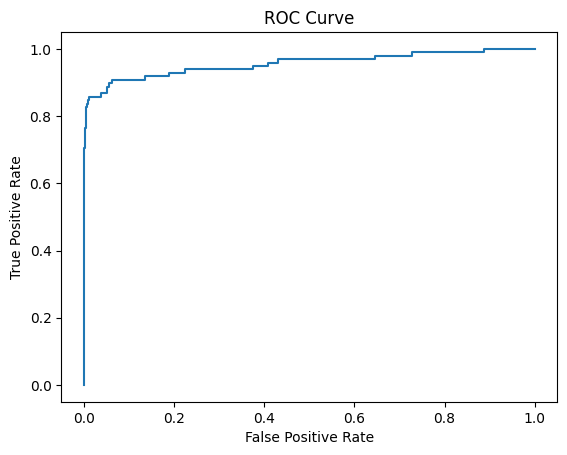

AUC:  0.9554129509147498


In [14]:
# Obtém as probabilidades da classe positiva, calcula a curva ROC (Taxa de Falsos Positivos vs. Verdadeiros Positivos),
# plota o gráfico do desempenho do modelo e exibe a pontuação AUC (área sob a curva).

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC: ", roc_auc_score(y_test, y_probs))


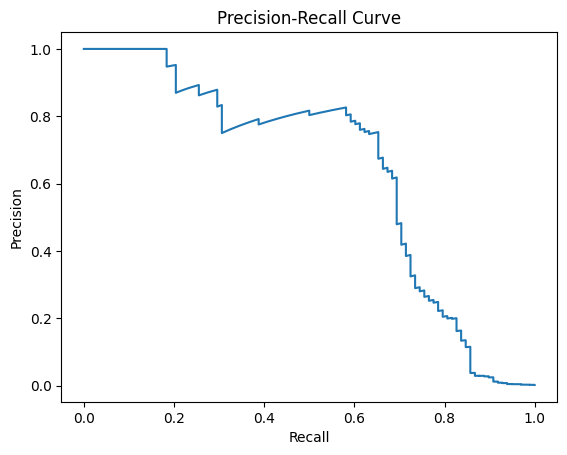

In [15]:
# Calcula a curva Precision-Recall variando os limiares de decisão e plota o gráficoda relação entre Precisão e Recall, ideal para avaliar modelos em bases de dados desbalanceadas.
from sklearn.metrics import precision_recall_curve

precisions, recalls, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recalls, precisions)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


# Baleceamento de dados

In [19]:
# Undersampling
# Aplica a técnica de Undersampling: isola todas as fraudes (classe 1) e escolhe aleatoriamente a mesma quantidade de transações normais (classe 0) para balancear as duas classes
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(n=len(fraudes), random_state=42)

df_undersampled = pd.concat([fraudes, normais])

In [20]:
# Oversampling
# Aplica a técnica de Oversampling com SMOTE: sintetiza novos exemplos da classe minoritária (fraudes)
# a partir da interpolação de vizinhos próximos, igualando a quantidade de instâncias
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_resampled, y_resampled = smote.fit_resample(x, y)


In [23]:
# Instancia e treina o algoritmo Random Forest configurado para dados desbalanceados (pesando mais a classe minoritária), limitando a profundidade das árvores e utilizando todos os núcleos do processador.
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.82      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [24]:
# Encapsula o pré-processamento (StandardScaler) e a modelagem (LogisticRegression) em um Pipeline do Scikit-Learn, garantindo que as transformações sejam aplicadas de forma sequencial e sem vazame
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

y_pred_pipeline = pipeline.predict(x_test)

print(classification_report(y_test, y_pred_pipeline))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.59      0.70        98

    accuracy                           1.00     56962
   macro avg       0.93      0.80      0.85     56962
weighted avg       1.00      1.00      1.00     56962



In [31]:
# Aplica um limiar (threshold) customizado de 0.3 sobre as probabilidades do modelo para reclassificar as previsões,
# aumentando a sensibilidade (Recall) para detectar a classe positiva (ex: fraudes).
thresholds = 0.3

y_pred_custom = (y_probs > thresholds).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.77      0.61      0.68        98

    accuracy                           1.00     56962
   macro avg       0.88      0.81      0.84     56962
weighted avg       1.00      1.00      1.00     56962



# Modelo Avançado - XGBoost

In [40]:
# Instancia e treina o modelo XGBoost atribuindo maior peso à classe minoritária (scale_pos_weight=10)
# para lidar com o desequilíbrio dos dados e gera as previsões no conjunto de teste.
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [23:11:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [41]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.83      0.89        98

    accuracy                           1.00     56962
   macro avg       0.98      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



# Importancia das variaveis

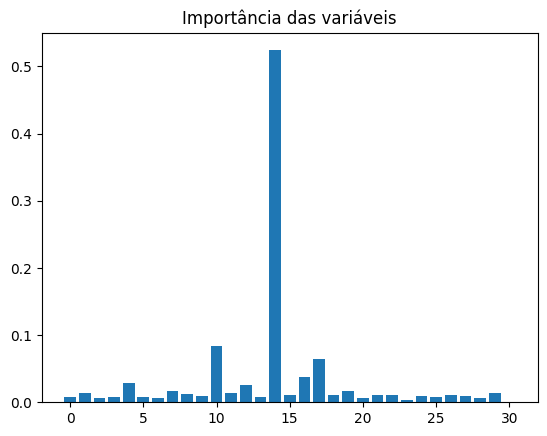

In [43]:
#Extrai as importâncias das variáveis calculadas pelo modelo XGBoost e gera um gráfico de barras exibindo o grau de contribuição de cada atributo para as decisões do modelo.
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()

# Ajuste de hiperparametros

In [45]:
# Executa o GridSearchCV para testar combinações de hiperparâmetros (profundidade e número de árvores)
# com validação cruzada (3 folds), otimizando o modelo XGBoost focado na métrica de Recall.
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, ],
    "n_estimators": [50, 100]
}

grid =  GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    cv=3,
    scoring="recall"
)

grid.fit(x_train, y_train)

print("Melhor modelo: " , grid.best_params_)
print("Melhor score: ", grid.best_score_)

Melhor modelo:  {'max_depth': 5, 'n_estimators': 50}
Melhor score:  0.7614889351530573


# Expicabilidade (SHAP)

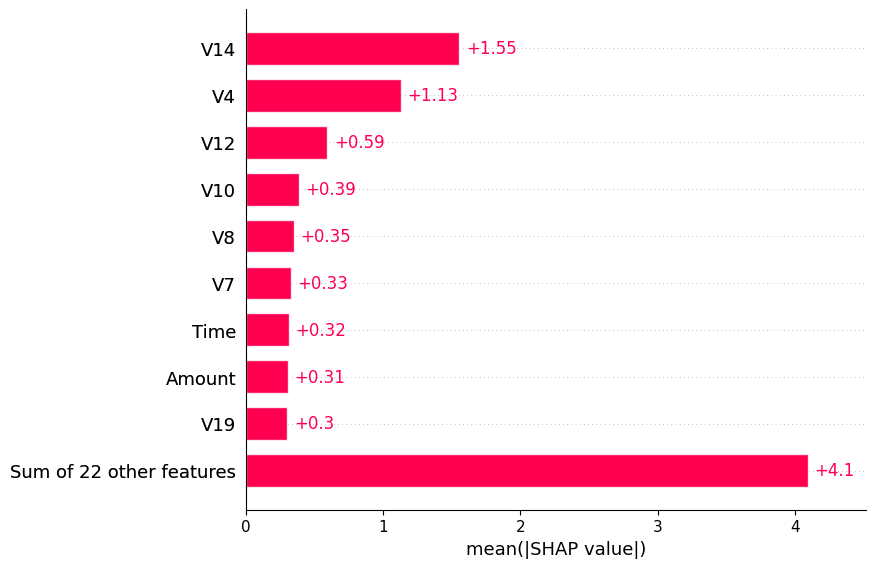

In [47]:
# Cria o explicador SHAP para o XGBoost e calcula os valores SHAP das primeiras 100 amostras de teste,
# gerando um gráfico de barras que ranqueia os atributos com maior impacto médio nas previsões do modelo.
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(x_test[:100])

shap.plots.bar(shap_values)